# VGG Pretrained Model in Keras

### Imports

In [1]:
!export 'TF_ENABLE_ONEDNN_OPTS'=0

In [2]:
import tensorflow as tf

# In keras.application you have available models 
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Additional utility 
import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1769787370.668466   35312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1769787370.701589   35312 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1769787371.635577   35312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Downloading & Loading the VGG16 Model

In [3]:
# Load the pre-trained VGG16 model from Keras applications
model = VGG16(weights='imagenet')

# Display model summary
model.summary()

W0000 00:00:1769787398.331650   35312 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1769787398.359809   35312 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1769787398.473792   35312 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1563 MB memory:  -> device: 0, name: NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.applications import VGG19
# Load the pre-trained VGG19 model from Keras applications
model = VGG19(weights='imagenet')

# Display model summary
model.summary()

### Prediction using the Pretrained Model

In [4]:
# Prediction Function
def predict_image(model, image_path):
    """
    Predicts the class of the given image using the VGG16 model.

    Args:
        model: Pre-trained VGG16 model.
        image_path: Path to the image file.

    Returns:
        Top predictions as a list of (class, description, score).
    """
    # Load the image with the required target size for VGG16
    img = load_img(image_path, target_size=(224, 224))

    # Convert the image to a numpy array
    img_array = img_to_array(img)

    # Add a batch dimension (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess the image for VGG16
    img_array = preprocess_input(img_array)

    # Predict the image class
    predictions = model.predict(img_array)

    # Decode the predictions into readable labels
    decoded_predictions = decode_predictions(predictions, top=5)  # Top 5 predictions
    return decoded_predictions[0]

### Paasing Images for Prediction

In [5]:
# Sample Image Prediction
sample_image_path = 'green_mamba.jpg'  # Replace with the path to your image

# Predict the image class
predictions = predict_image(model, sample_image_path)

# Display the predictions
print("Predictions:")
for i, (imagenet_id, label, score) in enumerate(predictions):
    print(f"{i + 1}: {label} ({score:.2f})")



I0000 00:00:1769787415.314706   35419 service.cc:153] XLA service 0x7792d4031760 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769787415.314803   35419 service.cc:161]   StreamExecutor [0]: NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU, Compute Capability 12.0a (Driver: 12.8.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1769787415.341086   35419 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769787415.465458   35419 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1769787415.709622   35510 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 8 bytes spill stores, 8 bytes spill loads

W0000 00:00:1769787426.205610   35419 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.06GiB (rounded to 2212102912)requested by op 
If the cause is

1/1 ━━━━━━━━━━━━━━━━━━━━ 100s 100s/step


I0000 00:00:1769787514.872945   35419 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Predictions:
1: green_mamba (0.60)
2: green_snake (0.35)
3: garter_snake (0.02)
4: vine_snake (0.01)
5: night_snake (0.01)


### Visualizing our Result

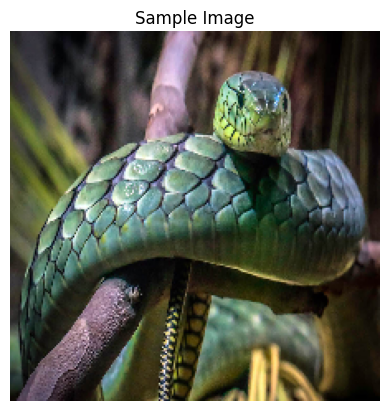

In [6]:
# Visualize the sample image
img = load_img(sample_image_path, target_size=(224, 224))
plt.imshow(img)
plt.title("Sample Image")
plt.axis('off')
plt.show()